# Import and Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
import json

from transformers import pipeline
from transformers import AutoTokenizer, AutoModelForSequenceClassification

d:\Hafiz\Portfolio\aetplh-game5-analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [35]:
pd.set_option('display.max_colwidth', 500)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [76]:
# Indonesian slang/informal text normalization dictionary
with open("../data/slang_dict.json", "r", encoding="utf-8") as f:
    SLANG_DICT = json.load(f)

print(f"Loaded {len(SLANG_DICT)} slang terms")

Loaded 214 slang terms


# Load Data

In [78]:
data_path = '../data/processed/processed_data.csv'
event_path = '../data/processed/event.csv'

df = pd.read_csv(data_path)
event_df = pd.read_csv(event_path)

# Normalize Time

In [79]:
def timestamp_to_seconds(time: str) -> int:
    """Convert a timestamp in 'HH:MM:SS' format to total seconds.

    Args:
        time (str): Timestamp in 'HH:MM:SS' format.

    Returns:
        int: Total seconds.
    """
    h, m, s = map(int, time.split(':'))
    return h * 3600 + m * 60 + s

def normalize_time(df: pd.DataFrame,
                   col_name: str, 
                   base_time: int) -> pd.DataFrame:
    """Normalize the time column in the DataFrame by subtracting the base time.

    Args:
        df (pd.DataFrame): DataFrame containing the time column.
        col_name (str): Name of the column to normalize.
        base_time (int): Base time in seconds to subtract.
    
    Returns:
        pd.DataFrame: DataFrame with normalized time column.
    """
    df[col_name] = df[col_name].apply(lambda x: timestamp_to_seconds(x) - base_time)
    return df

In [80]:
base_time = timestamp_to_seconds(df['occurence_timestamp'].iloc[0])
print(f"Base time (in seconds): {base_time}")

print("Normalizing 'occurence_timestamp' in df\n")
normalized_df = normalize_time(df, 'occurence_timestamp', base_time)
normalized_df.head()

Base time (in seconds): 12330
Normalizing 'occurence_timestamp' in df



,message_type,occurence_timestamp,timeStampUTC,author,content,message,emoji,text_content
0,Chat Message,0,2026-01-24 10:50:55.099409,@yamin12345-z,"{'message': '#7 ', 'emoji': [], 'text_content': '#7 '}",#7,[],#7
1,Chat Message,0,2026-01-24 10:50:55.222274,@fdoniaquilani9902,"{'message': 'Suport Indo ', 'emoji': [], 'text_content': 'Suport Indo '}",Suport Indo,[],Suport Indo
2,Chat Message,0,2026-01-24 10:50:55.256967,@theycalledmeamadman2772,"{'message': 'ONIC MANA BISA ', 'emoji': [], 'text_content': 'ONIC MANA BISA '}",ONIC MANA BISA,[],ONIC MANA BISA
3,Chat Message,0,2026-01-24 10:50:55.363708,@loveydumpies,"{'message': 'AE plss ', 'emoji': [], 'text_content': 'AE plss '}",AE plss,[],AE plss
4,Chat Message,0,2026-01-24 10:50:55.592918,@Amrik199,"{'message': 'hina AE biar menang terus ', 'emoji': [], 'text_content': 'hina AE biar menang terus '}",hina AE biar menang terus,[],hina AE biar menang terus


In [81]:
print("Normalizing 'timestamp' in event_df\n")
normalized_event_df = normalize_time(event_df, 'timestamp', base_time)
normalized_event_df.head()

Normalizing 'timestamp' in event_df



,event_id,timestamp,event,team,detail
0,E01,0,draft_dimulai,NaN,Fase draft Game 5 dimulai
1,E02,47,draft_pick,Alter Ego,Alter Ego memilih hero Uranus
2,E03,237,draft_unpredictable,Alter Ego,Uranus digunakan sebagai jungler dan draft selesai
3,E04,404,turtle_spawn_1,NaN,Turtle pertama muncul
4,E05,413,first_blood,Team Liquid,Team Liquid mendapatkan first blood sekaligus turtle pertama


In [82]:
normalized_df = normalized_df[['occurence_timestamp', 'text_content']]

# Data Preprocessing

In [83]:
# drop rows with missing rows
print(f"Before dropping NA: {normalized_df.shape}")
normalized_df.dropna(axis=0, inplace=True)
print(f"After dropping NA: {normalized_df.shape}")

Before dropping NA: (16864, 2)
After dropping NA: (16803, 2)


In [84]:
def normalize_slang(text: str) -> str:
    """Normalize Indonesian slang words to standard form.
    
    Args:
        text (str): Text with potential slang words.
    
    Returns:
        str: Text with slang words normalized.
    """
    words = text.split()
    normalized_words = [SLANG_DICT.get(word, word) for word in words]
    return ' '.join(normalized_words)


def preprocess_text(text: str) -> str:
    """Preprocess text for sentiment analysis (without stemming for IndoBERT).
    
    Steps:
    1. Convert to lowercase
    2. Remove URLs
    3. Remove special characters and symbols (keep alphanumeric and spaces)
    4. Normalize slang words
    5. Remove extra spaces

    Args:
        text (str): Original text.

    Returns:
        str: Preprocessed text.
    """
    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove special characters and symbols (keep letters, numbers, spaces)
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Normalize slang words
    text = normalize_slang(text)

    return text

In [85]:
print("Preprocessing 'text_content' in normalized_df\n")
normalized_df['cleaned_text'] = normalized_df['text_content'].apply(preprocess_text)
normalized_df.head()

Preprocessing 'text_content' in normalized_df



,occurence_timestamp,text_content,cleaned_text
0,0,#7,7
1,0,Suport Indo,suport indo
2,0,ONIC MANA BISA,onic mana bisa
3,0,AE plss,ae tolong
4,0,hina AE biar menang terus,hina ae biar menang terus


In [86]:
# Filter out empty and very short texts (less than 3 characters)
MIN_TEXT_LENGTH = 3

before_filter = len(normalized_df)
normalized_df = normalized_df[normalized_df['cleaned_text'].str.len() >= MIN_TEXT_LENGTH].copy()
after_filter = len(normalized_df)

print(f"Filtered short texts (< {MIN_TEXT_LENGTH} chars):")
print(f"  Before: {before_filter:,} comments")
print(f"  After:  {after_filter:,} comments")
print(f"  Removed: {before_filter - after_filter:,} comments ({(before_filter - after_filter) / before_filter * 100:.2f}%)")

Filtered short texts (< 3 chars):
  Before: 16,803 comments
  After:  15,882 comments
  Removed: 921 comments (5.48%)


In [87]:
# Sample validation: Compare original vs cleaned text
print("Sample Validation: Original vs Cleaned Text")
print("=" * 80)

sample_df = normalized_df.sample(15, random_state=42)[['text_content', 'cleaned_text']]
for idx, row in sample_df.iterrows():
    print(f"Original:  {row['text_content']}")
    print(f"Cleaned:   {row['cleaned_text']}")
    print("-" * 80)

Sample Validation: Original vs Cleaned Text
Original:  IMPOSTOR 
Cleaned:   impostor
--------------------------------------------------------------------------------
Original:  AE pulang 
Cleaned:   ae pulang
--------------------------------------------------------------------------------
Original:  kureng cc 
Cleaned:   kureng crowd control
--------------------------------------------------------------------------------
Original:  GELOO 
Cleaned:   geloo
--------------------------------------------------------------------------------
Original:  PLISSSS JANGAN BLUNDER 
Cleaned:   plissss jangan blunder
--------------------------------------------------------------------------------
Original:  RRQ CHAMPION M7...GO GO RRQ....YANG LAEN SUNGKEM DULU.... 
Cleaned:   rrq champion m7go go rrqyang laen sungkem dulu
--------------------------------------------------------------------------------
Original:  tunggu late game bos ae menang 
Cleaned:   tunggu late game bos ae menang
---------------

# Event Categorization

In [61]:
EVENT_CATEGORIES = {
    'major': {
        'events': ['war_besar_lord', 'war_besar_turtle', 'war_besar_base', 
                   'match_selesai', 'perubahan_momentum'],
        'window_seconds': 90
    },
    'medium': {
        'events': ['first_blood', 'first_turret', 'lord_diamankan', 
                   'defend_lord', 'draft_unpredictable'],
        'window_seconds': 60
    },
    'minor': {
        'events': ['draft_dimulai', 'draft_pick', 'turtle_spawn_1', 
                   'turtle_spawn_3', 'lord_spawn_1', 'lord_spawn_2',
                   'kill', 'skirmish_trade', 'pickoff', 'highlight_replay'],
        'window_seconds': 30
    }
}

In [62]:
def get_event_category(event_name: str) -> str:
    """Get the category (major/medium/minor) for an event.
    
    Args:
        event_name: The event type name
    
    Returns:
        Category string: 'major', 'medium', or 'minor'
    """
    for category, config in EVENT_CATEGORIES.items():
        if event_name in config['events']:
            return category
    return 'minor'  # Default to minor for unknown events


def get_window_seconds(event_name: str) -> int:
    """Get the window size in seconds for an event.
    
    Args:
        event_name: The event type name
    
    Returns:
        Window size in seconds
    """
    category = get_event_category(event_name)
    return EVENT_CATEGORIES[category]['window_seconds']

In [88]:
# Apply categorization to event dataframe
normalized_event_df['category'] = normalized_event_df['event'].apply(get_event_category)
normalized_event_df['window_seconds'] = normalized_event_df['event'].apply(get_window_seconds)

# Calculate window boundaries (start and end times)
normalized_event_df['window_start'] = normalized_event_df['timestamp'] - normalized_event_df['window_seconds']
normalized_event_df['window_end'] = normalized_event_df['timestamp'] + normalized_event_df['window_seconds']

# Ensure window_start doesn't go below 0
normalized_event_df['window_start'] = normalized_event_df['window_start'].clip(lower=0)

normalized_event_df[['event_id', 'timestamp', 'event', 'category', 'window_seconds', 'window_start', 'window_end']]

,event_id,timestamp,event,category,window_seconds,window_start,window_end
0,E01,0,draft_dimulai,minor,30,0,30
1,E02,47,draft_pick,minor,30,17,77
2,E03,237,draft_unpredictable,medium,60,177,297
3,E04,404,turtle_spawn_1,minor,30,374,434
4,E05,413,first_blood,medium,60,353,473
5,E06,623,first_turret,medium,60,563,683
6,E07,640,kill,minor,30,610,670
7,E08,649,skirmish_trade,minor,30,619,679
8,E09,675,turtle_spawn_3,minor,30,645,705
9,E10,713,war_besar_turtle,major,90,623,803


In [89]:
# Summary of event categories
print("Event Category Summary:")
print("=" * 50)
for category in ['major', 'medium', 'minor']:
    count = (normalized_event_df['category'] == category).sum()
    window = EVENT_CATEGORIES[category]['window_seconds']
    print(f"{category.upper():8} | {count:2} events | ±{window}s window")
print("=" * 50)
print(f"Total: {len(normalized_event_df)} events")

Event Category Summary:
MAJOR    |  6 events | ±90s window
MEDIUM   |  6 events | ±60s window
MINOR    | 10 events | ±30s window
Total: 22 events


# Extract Comments per Event Window

In [90]:
def extract_comments_in_window(comments_df: pd.DataFrame, 
                                window_start: int, 
                                window_end: int) -> pd.DataFrame:
    """Extract comments that fall within a time window.
    
    Args:
        comments_df: DataFrame with 'occurence_timestamp' column
        window_start: Start of window (in seconds)
        window_end: End of window (in seconds)
    
    Returns:
        Filtered DataFrame with comments in the window
    """
    mask = (comments_df['occurence_timestamp'] >= window_start) & \
           (comments_df['occurence_timestamp'] <= window_end)
    return comments_df[mask].copy()

In [91]:
# Preview: Count comments per event window
print("Comments per Event Window:")
print("=" * 70)
print(f"{'Event ID':<10} {'Event':<25} {'Category':<8} {'Comments':>10}")
print("-" * 70)

for _, event_row in normalized_event_df.iterrows():
    comments_in_window = extract_comments_in_window(
        normalized_df,
        event_row['window_start'],
        event_row['window_end']
    )
    print(f"{event_row['event_id']:<10} {event_row['event']:<25} {event_row['category']:<8} {len(comments_in_window):>10}")

print("=" * 70)

Comments per Event Window:
Event ID   Event                     Category   Comments
----------------------------------------------------------------------
E01        draft_dimulai             minor           261
E02        draft_pick                minor           556
E03        draft_unpredictable       medium         1095
E04        turtle_spawn_1            minor           494
E05        first_blood               medium         1120
E06        first_turret              medium         1298
E07        kill                      minor           664
E08        skirmish_trade            minor           652
E09        turtle_spawn_3            minor           655
E10        war_besar_turtle          major          1875
E11        lord_spawn_1              minor           675
E12        pickoff                   minor           536
E13        war_besar_lord            major          1449
E14        perubahan_momentum        major          1612
E15        defend_lord               medium    

# Exploratory Data Analysis (EDA)

In [67]:
# Basic statistics
print("Dataset Statistics")
print("=" * 50)
print(f"Total comments: {len(normalized_df):,}")
print(f"Time range: {normalized_df['occurence_timestamp'].min()}s - {normalized_df['occurence_timestamp'].max()}s")
print(f"Duration: {(normalized_df['occurence_timestamp'].max() - normalized_df['occurence_timestamp'].min()) / 60:.1f} minutes")
print()

# Text length statistics
normalized_df['text_length'] = normalized_df['cleaned_text'].str.len()
print("Text Length Statistics:")
print(f"  Mean:   {normalized_df['text_length'].mean():.1f} chars")
print(f"  Median: {normalized_df['text_length'].median():.1f} chars")
print(f"  Min:    {normalized_df['text_length'].min()} chars")
print(f"  Max:    {normalized_df['text_length'].max()} chars")

Dataset Statistics
Total comments: 15,882
Time range: 0s - 1629s
Duration: 27.1 minutes

Text Length Statistics:
  Mean:   16.0 chars
  Median: 12.0 chars
  Min:    3 chars
  Max:    205 chars


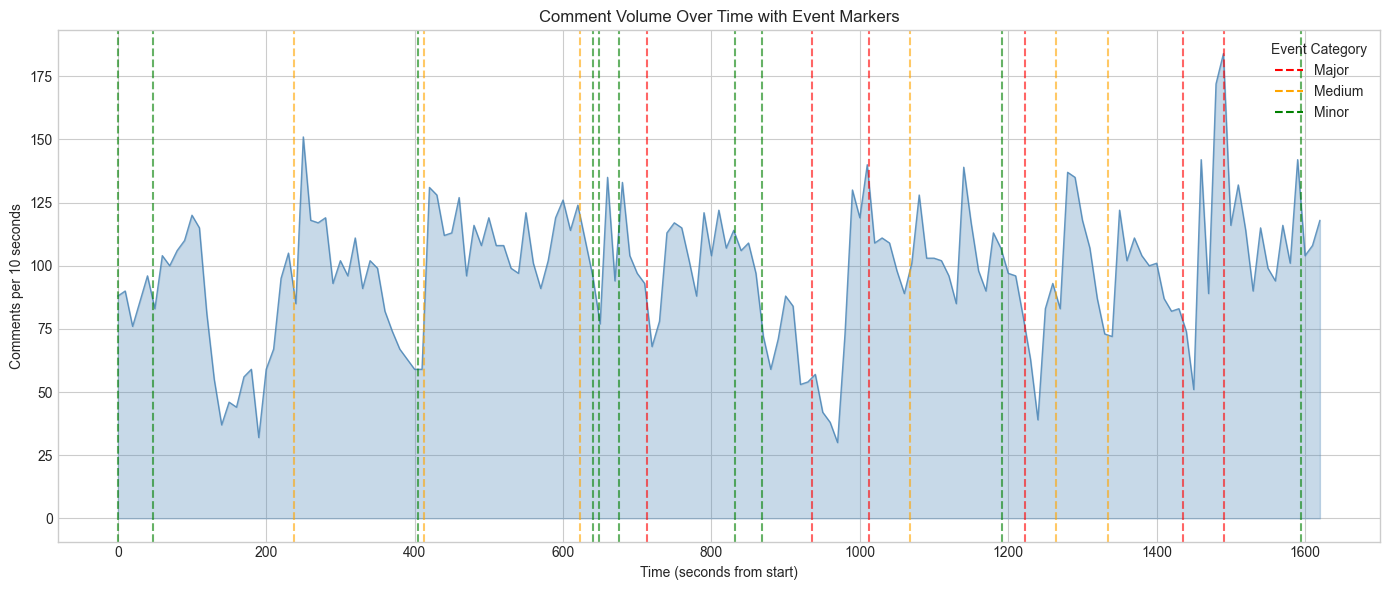

In [68]:
# Comment volume over time
fig, ax = plt.subplots(figsize=(14, 6))

# Group comments by 10-second intervals
normalized_df['time_bin'] = (normalized_df['occurence_timestamp'] // 10) * 10
volume_over_time = normalized_df.groupby('time_bin').size()

ax.plot(volume_over_time.index, volume_over_time.values, linewidth=1, alpha=0.8, color='steelblue')
ax.fill_between(volume_over_time.index, volume_over_time.values, alpha=0.3, color='steelblue')

# Mark events on the timeline
colors = {'major': 'red', 'medium': 'orange', 'minor': 'green'}
for _, event in normalized_event_df.iterrows():
    ax.axvline(x=event['timestamp'], color=colors[event['category']], 
               alpha=0.6, linestyle='--', linewidth=1.5)

# Add legend for event categories
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=c, linestyle='--', label=cat.capitalize()) 
                   for cat, c in colors.items()]
ax.legend(handles=legend_elements, loc='upper right', title='Event Category')

ax.set_xlabel('Time (seconds from start)')
ax.set_ylabel('Comments per 10 seconds')
ax.set_title('Comment Volume Over Time with Event Markers')
plt.tight_layout()
plt.show()

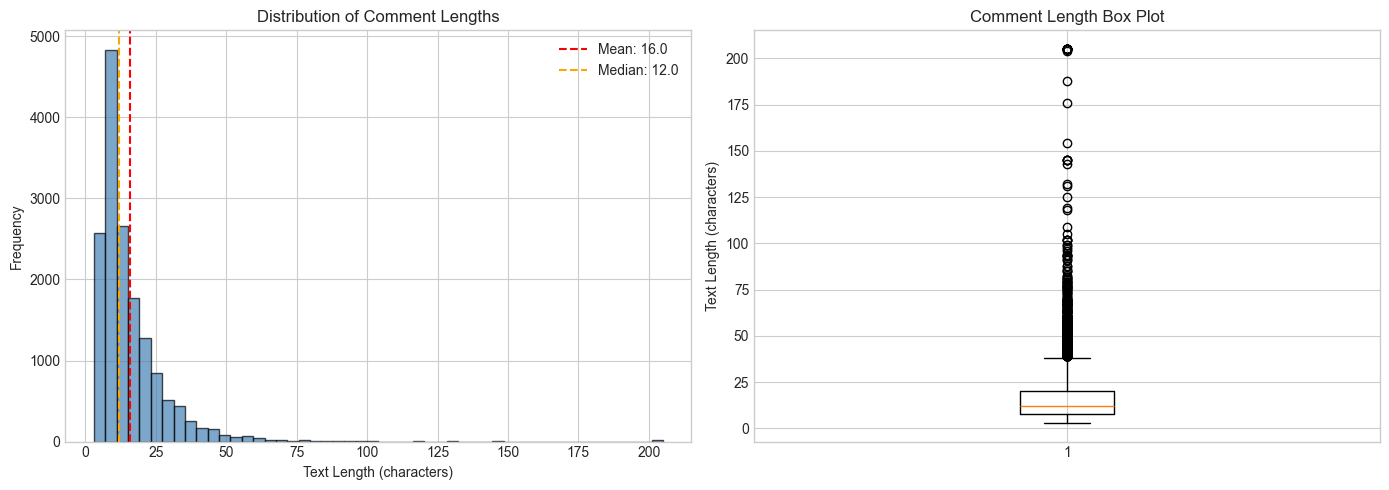

In [69]:
# Text length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(normalized_df['text_length'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(x=normalized_df['text_length'].mean(), color='red', linestyle='--', label=f"Mean: {normalized_df['text_length'].mean():.1f}")
axes[0].axvline(x=normalized_df['text_length'].median(), color='orange', linestyle='--', label=f"Median: {normalized_df['text_length'].median():.1f}")
axes[0].set_xlabel('Text Length (characters)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Comment Lengths')
axes[0].legend()

# Box plot
axes[1].boxplot(normalized_df['text_length'], vert=True)
axes[1].set_ylabel('Text Length (characters)')
axes[1].set_title('Comment Length Box Plot')

plt.tight_layout()
plt.show()

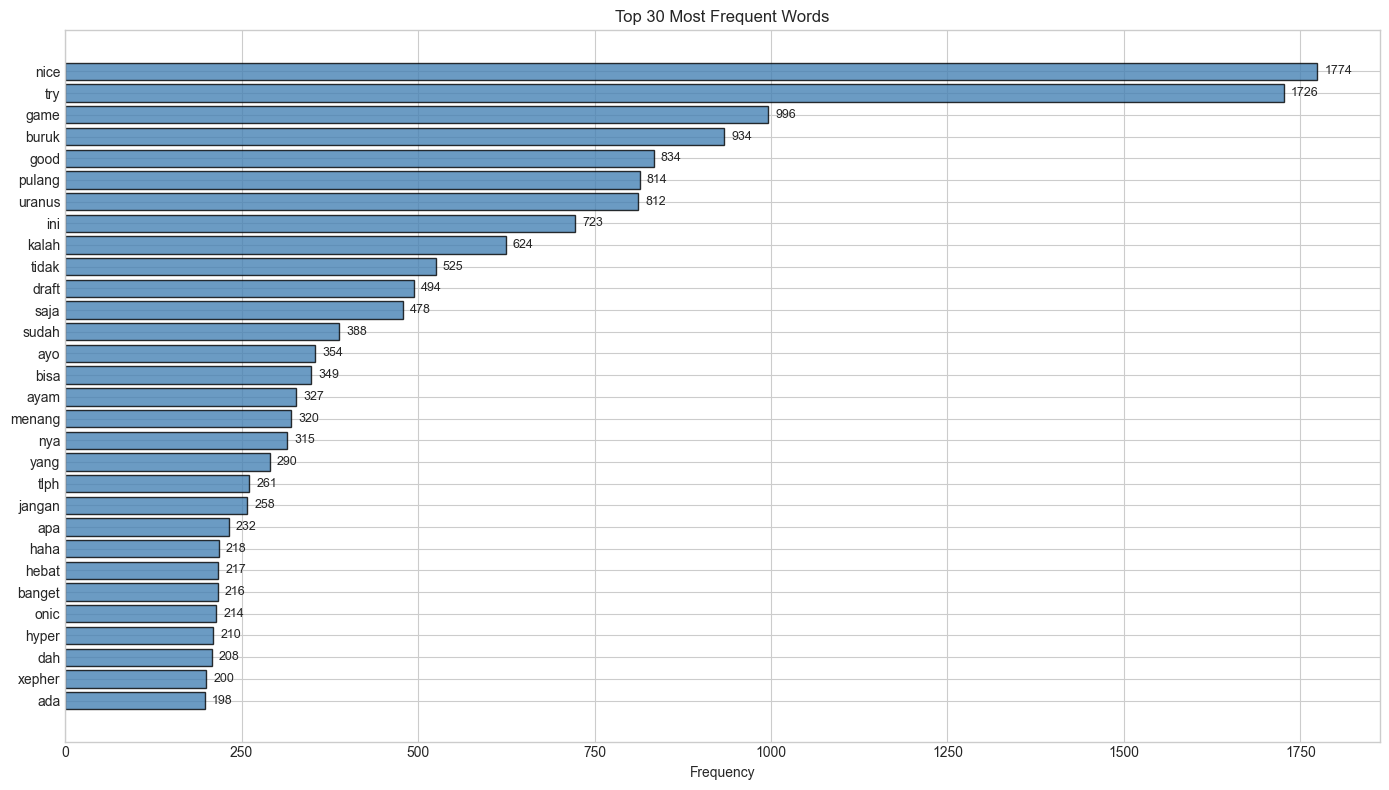


Total unique words: 5,722
Total words: 48,413


In [70]:
# Word frequency analysis
all_words = ' '.join(normalized_df['cleaned_text']).split()
word_counts = Counter(all_words)

# Filter out very short words and numbers
word_counts_filtered = {k: v for k, v in word_counts.items() if len(k) > 2 and not k.isdigit()}
top_words = Counter(word_counts_filtered).most_common(30)

# Plot top words
fig, ax = plt.subplots(figsize=(14, 8))
words, counts = zip(*top_words)
y_pos = range(len(words))

ax.barh(y_pos, counts, color='steelblue', edgecolor='black', alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(words)
ax.invert_yaxis()  # Top words at the top
ax.set_xlabel('Frequency')
ax.set_title('Top 30 Most Frequent Words')

# Add count labels
for i, count in enumerate(counts):
    ax.text(count + 10, i, str(count), va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nTotal unique words: {len(word_counts_filtered):,}")
print(f"Total words: {len(all_words):,}")

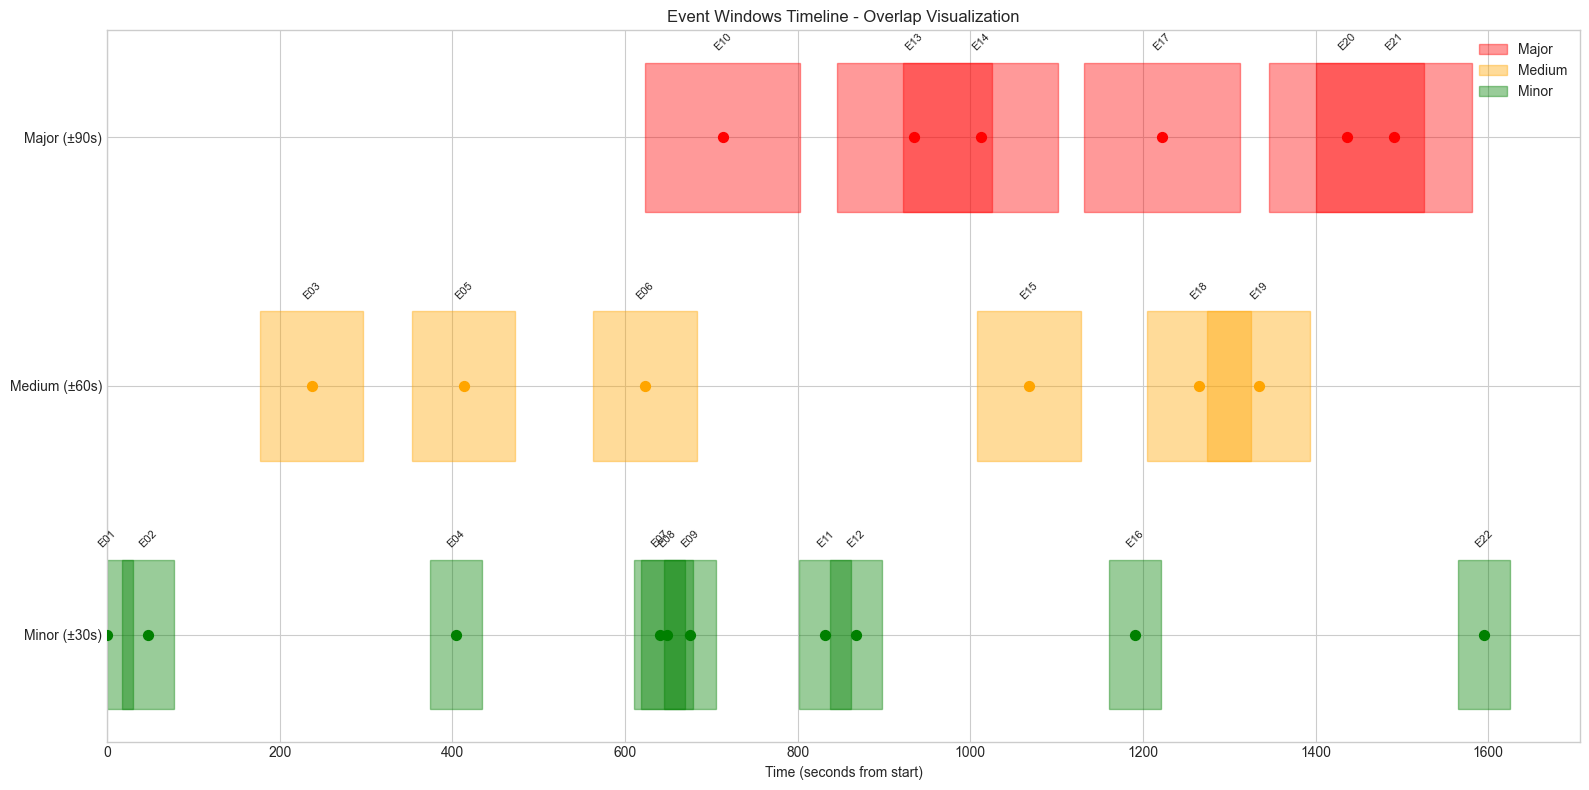


Overlapping Event Windows:
E01 (draft_dimulai) overlaps with: E02
E02 (draft_pick) overlaps with: E01
E04 (turtle_spawn_1) overlaps with: E05
E05 (first_blood) overlaps with: E04
E06 (first_turret) overlaps with: E07, E08, E09, E10
E07 (kill) overlaps with: E06, E08, E09, E10
E08 (skirmish_trade) overlaps with: E06, E07, E09, E10
E09 (turtle_spawn_3) overlaps with: E06, E07, E08, E10
E10 (war_besar_turtle) overlaps with: E06, E07, E08, E09, E11
E11 (lord_spawn_1) overlaps with: E10, E12, E13
E12 (pickoff) overlaps with: E11, E13
E13 (war_besar_lord) overlaps with: E11, E12, E14, E15
E14 (perubahan_momentum) overlaps with: E13, E15
E15 (defend_lord) overlaps with: E13, E14
E16 (lord_spawn_2) overlaps with: E17, E18
E17 (war_besar_lord) overlaps with: E16, E18, E19
E18 (lord_diamankan) overlaps with: E16, E17, E19
E19 (defend_lord) overlaps with: E17, E18, E20
E20 (war_besar_base) overlaps with: E19, E21
E21 (match_selesai) overlaps with: E20, E22
E22 (highlight_replay) overlaps with: E

In [71]:
# Window overlap visualization
fig, ax = plt.subplots(figsize=(16, 8))

colors = {'major': 'red', 'medium': 'orange', 'minor': 'green'}
y_offset = {'major': 2, 'medium': 1, 'minor': 0}

for idx, event in normalized_event_df.iterrows():
    category = event['category']
    y = y_offset[category]
    
    # Draw window range
    ax.barh(y, event['window_end'] - event['window_start'], 
            left=event['window_start'], height=0.6, 
            color=colors[category], alpha=0.4, edgecolor=colors[category])
    
    # Mark event center
    ax.scatter(event['timestamp'], y, color=colors[category], s=50, zorder=5)
    
    # Add event label
    ax.text(event['timestamp'], y + 0.35, event['event_id'], 
            ha='center', fontsize=8, rotation=45)

ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['Minor (±30s)', 'Medium (±60s)', 'Major (±90s)'])
ax.set_xlabel('Time (seconds from start)')
ax.set_title('Event Windows Timeline - Overlap Visualization')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, alpha=0.4, edgecolor=c, label=cat.capitalize()) 
                   for cat, c in colors.items()]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

# Print overlapping windows
print("\nOverlapping Event Windows:")
print("=" * 60)
for i, e1 in normalized_event_df.iterrows():
    overlaps = []
    for j, e2 in normalized_event_df.iterrows():
        if i != j:
            # Check if windows overlap
            if e1['window_start'] <= e2['window_end'] and e1['window_end'] >= e2['window_start']:
                overlaps.append(e2['event_id'])
    if overlaps:
        print(f"{e1['event_id']} ({e1['event']}) overlaps with: {', '.join(overlaps)}")

# IndoBERT Sentiment Analysis

In [92]:
# Raw
pretrained= "mdhugol/indonesia-bert-sentiment-classification"

model = AutoModelForSequenceClassification.from_pretrained(pretrained)
tokenizer = AutoTokenizer.from_pretrained(pretrained)

sentiment_analysis = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

label_index = {'LABEL_0': 'positive', 'LABEL_1': 'neutral', 'LABEL_2': 'negative'}

pos_text = "Sangat bahagia hari ini"
neg_text = "Dasar anak sialan!! Kurang ajar!!"

result = sentiment_analysis(pos_text)
status = label_index[result[0]['label']]
score = result[0]['score']
print(f'Text: {pos_text} | Label : {status} ({score * 100:.3f}%)')

result = sentiment_analysis(neg_text)
status = label_index[result[0]['label']]
score = result[0]['score']
print(f'Text: {neg_text} | Label : {status} ({score * 100:.3f}%)')


d:\Hafiz\Portfolio\aetplh-game5-analysis\.venv\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\HP\.cache\huggingface\hub\models--mdhugol--indonesia-bert-sentiment-classification. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 201/201 [00:01<00:00, 195.72it/s, Materiali

Text: Sangat bahagia hari ini | Label : positive (98.457%)
Text: Dasar anak sialan!! Kurang ajar!! | Label : negative (97.866%)


In [95]:
from tqdm import tqdm

def analyze_sentiment_batch(texts: list, batch_size: int = 32) -> list:
    """Analyze sentiment for a list of texts in batches.
    
    Args:
        texts: List of text strings to analyze
        batch_size: Number of texts to process per batch
    
    Returns:
        List of sentiment labels ('positive', 'negative', 'neutral')
    """
    results = []
    
    for i in tqdm(range(0, len(texts), batch_size), desc="Analyzing sentiment"):
        batch = texts[i:i + batch_size]
        
        # Handle empty strings
        batch_cleaned = [text if text.strip() else "neutral" for text in batch]
        
        try:
            batch_results = sentiment_analysis(batch_cleaned)
            for result in batch_results:
                label = label_index[result['label']]
                results.append(label)
        except Exception as e:
            print(f"Error processing batch {i}: {e}")
            # Default to neutral on error
            results.extend(['neutral'] * len(batch))
    
    return results

In [96]:
# Run sentiment analysis on all comments
print(f"Starting sentiment analysis on {len(normalized_df):,} comments...")
print()

texts_list = normalized_df['cleaned_text'].tolist()
sentiment_labels = analyze_sentiment_batch(texts_list, batch_size=32)

# Add sentiment column to dataframe
normalized_df['sentiment'] = sentiment_labels

print(f"\nSentiment analysis complete!")
print(f"Results: {normalized_df['sentiment'].value_counts().to_dict()}")

Starting sentiment analysis on 15,882 comments...



Analyzing sentiment: 100%|██████████| 497/497 [21:29<00:00,  2.60s/it]  



Sentiment analysis complete!
Results: {'negative': 8119, 'positive': 5905, 'neutral': 1858}


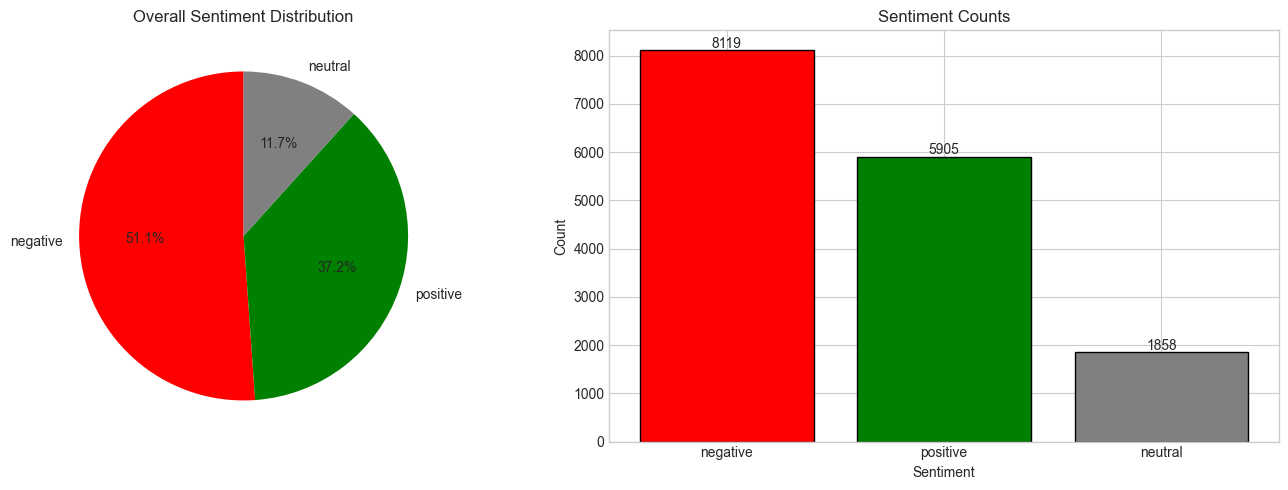

In [97]:
# Overall sentiment distribution
sentiment_counts = normalized_df['sentiment'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
colors = {'positive': 'green', 'neutral': 'gray', 'negative': 'red'}
axes[0].pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%',
            colors=[colors[s] for s in sentiment_counts.index], startangle=90)
axes[0].set_title('Overall Sentiment Distribution')

# Bar chart
axes[1].bar(sentiment_counts.index, sentiment_counts.values, 
            color=[colors[s] for s in sentiment_counts.index], edgecolor='black')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Count')
axes[1].set_title('Sentiment Counts')

for i, (label, count) in enumerate(sentiment_counts.items()):
    axes[1].text(i, count + 50, str(count), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Aggregate Sentiment per Event

In [98]:
def aggregate_event_sentiment(event_df: pd.DataFrame, comments_df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate sentiment metrics for each event window.
    
    Args:
        event_df: DataFrame with event information and window boundaries
        comments_df: DataFrame with comments and sentiment labels
    
    Returns:
        DataFrame with aggregated sentiment per event
    """
    results = []
    
    for _, event in event_df.iterrows():
        # Extract comments in window
        window_comments = extract_comments_in_window(
            comments_df, 
            event['window_start'], 
            event['window_end']
        )
        
        total = len(window_comments)
        
        if total > 0:
            sentiment_counts = window_comments['sentiment'].value_counts()
            positive = sentiment_counts.get('positive', 0)
            negative = sentiment_counts.get('negative', 0)
            neutral = sentiment_counts.get('neutral', 0)
            
            # Sentiment score: (positive - negative) / total, range [-1, 1]
            sentiment_score = (positive - negative) / total
        else:
            positive, negative, neutral = 0, 0, 0
            sentiment_score = 0.0
        
        results.append({
            'event_id': event['event_id'],
            'timestamp': event['timestamp'],
            'event': event['event'],
            'team': event['team'],
            'detail': event['detail'],
            'category': event['category'],
            'window_seconds': event['window_seconds'],
            'total_comments': total,
            'positive': positive,
            'negative': negative,
            'neutral': neutral,
            'sentiment_score': round(sentiment_score, 4)
        })
    
    return pd.DataFrame(results)

# Aggregate sentiment per event
event_sentiment_df = aggregate_event_sentiment(normalized_event_df, normalized_df)
event_sentiment_df

,event_id,timestamp,event,team,detail,category,window_seconds,total_comments,positive,negative,neutral,sentiment_score
0,E01,0,draft_dimulai,NaN,Fase draft Game 5 dimulai,minor,30,261,82,124,55,-0.1609
1,E02,47,draft_pick,Alter Ego,Alter Ego memilih hero Uranus,minor,30,556,167,306,83,-0.2500
2,E03,237,draft_unpredictable,Alter Ego,Uranus digunakan sebagai jungler dan draft selesai,medium,60,1095,439,492,164,-0.0484
3,E04,404,turtle_spawn_1,NaN,Turtle pertama muncul,minor,30,494,219,222,53,-0.0061
4,E05,413,first_blood,Team Liquid,Team Liquid mendapatkan first blood sekaligus turtle pertama,medium,60,1120,474,515,131,-0.0366
5,E06,623,first_turret,Team Liquid,Team Liquid menghancurkan turret pertama,medium,60,1298,413,748,137,-0.2581
6,E07,640,kill,Alter Ego,Kill pertama untuk Alter Ego,minor,30,664,215,370,79,-0.2334
7,E08,649,skirmish_trade,Both,Alter Ego mendapatkan 2 kill namun dibalas dengan double kill oleh Team Liquid,minor,30,652,216,365,71,-0.2285
8,E09,675,turtle_spawn_3,NaN,Turtle ketiga muncul,minor,30,655,212,350,93,-0.2107
9,E10,713,war_besar_turtle,Both,Team Liquid mengamankan turtle namun Alter Ego menukar dengan 2 kill meskipun kehilangan 1 pemain,major,90,1875,577,1044,254,-0.2491


In [99]:
# Export to CSV
output_path = '../data/processed/event_sentiment.csv'
event_sentiment_df.to_csv(output_path, index=False)
print(f"Exported event sentiment data to: {output_path}")
print(f"Total events: {len(event_sentiment_df)}")

Exported event sentiment data to: ../data/processed/event_sentiment.csv
Total events: 22


In [105]:
# Export to CSV
output_path = '../data/processed/comment_sentiment.csv'
normalized_df.to_csv(output_path, index=False)
print(f"Exported comment sentiment data to: {output_path}")
print(f"Total comments: {len(normalized_df)}")

Exported comment sentiment data to: ../data/processed/comment_sentiment.csv
Total comments: 15882


# Sentiment Visualizations

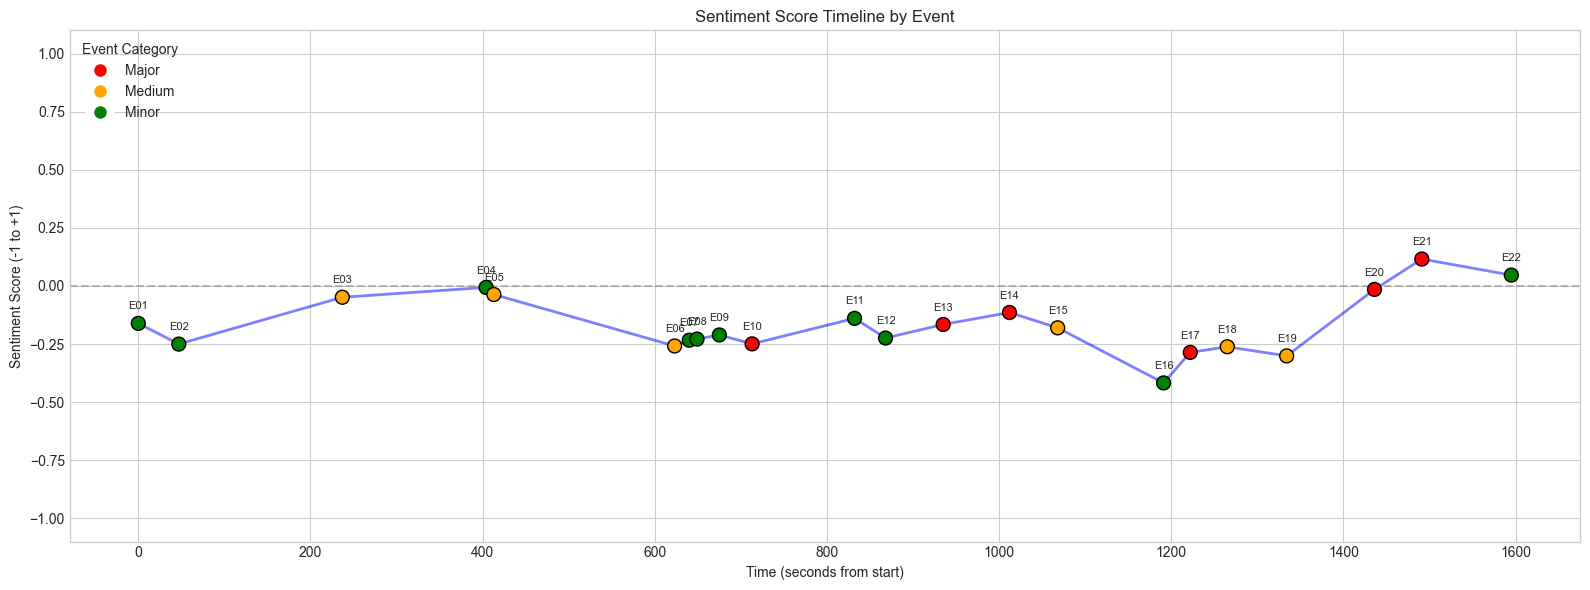

In [100]:
# Sentiment Timeline
fig, ax = plt.subplots(figsize=(16, 6))

# Plot sentiment score line
colors_cat = {'major': 'red', 'medium': 'orange', 'minor': 'green'}
scatter_colors = [colors_cat[cat] for cat in event_sentiment_df['category']]

ax.plot(event_sentiment_df['timestamp'], event_sentiment_df['sentiment_score'], 
        'b-', alpha=0.5, linewidth=2, label='Sentiment Score')
ax.scatter(event_sentiment_df['timestamp'], event_sentiment_df['sentiment_score'], 
           c=scatter_colors, s=100, zorder=5, edgecolors='black')

# Add event labels
for _, event in event_sentiment_df.iterrows():
    ax.annotate(event['event_id'], 
                (event['timestamp'], event['sentiment_score']),
                textcoords="offset points", xytext=(0, 10), ha='center', fontsize=8)

# Reference lines
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5, label='Neutral')

# Legend for categories
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c, 
                          markersize=10, label=cat.capitalize()) 
                   for cat, c in colors_cat.items()]
ax.legend(handles=legend_elements, loc='upper left', title='Event Category')

ax.set_xlabel('Time (seconds from start)')
ax.set_ylabel('Sentiment Score (-1 to +1)')
ax.set_title('Sentiment Score Timeline by Event')
ax.set_ylim(-1.1, 1.1)

plt.tight_layout()
plt.show()

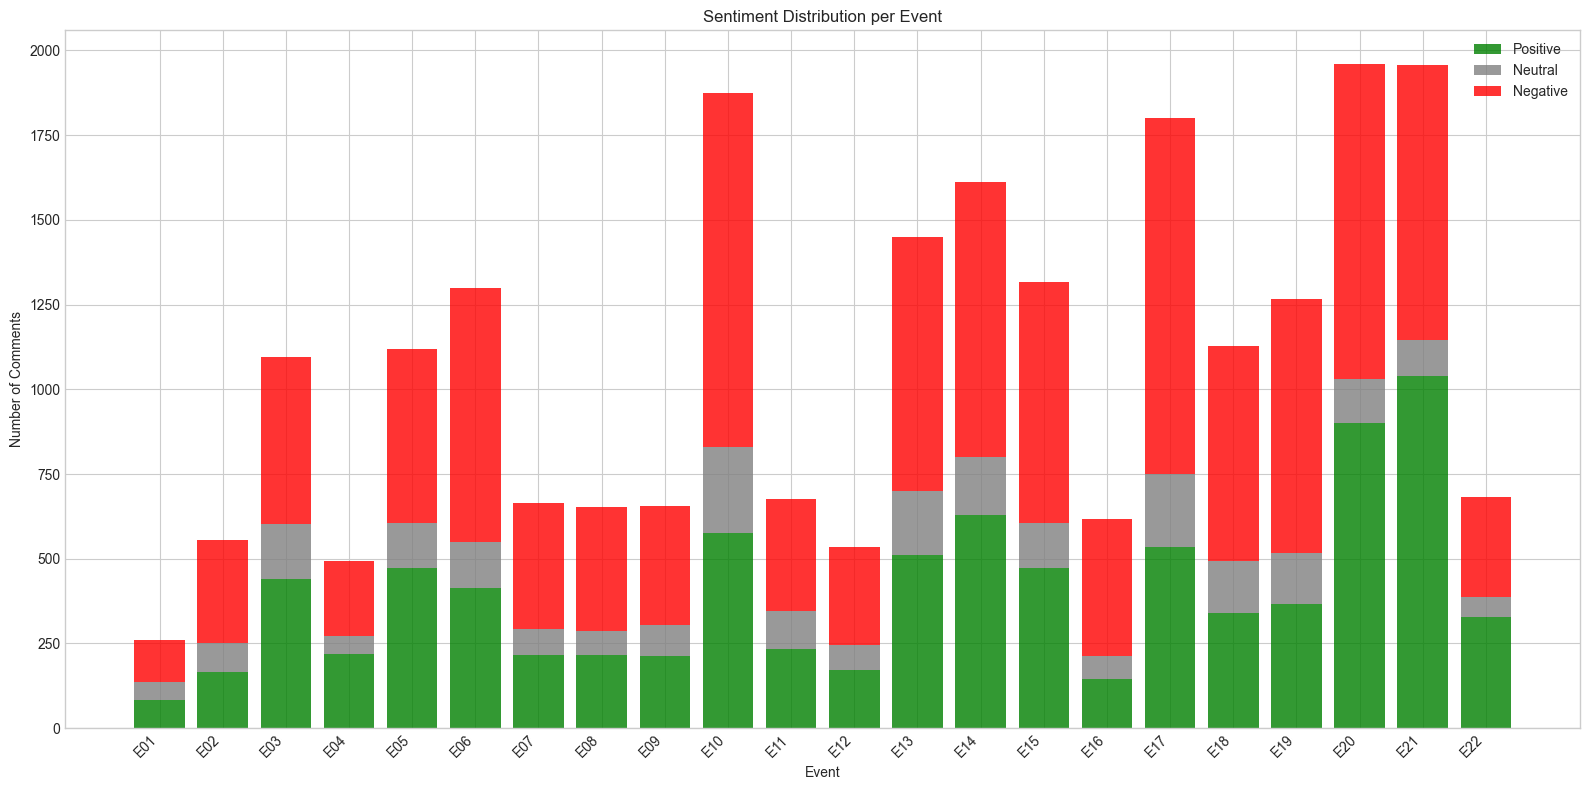

In [101]:
# Stacked bar chart: Positive/Negative/Neutral per event
fig, ax = plt.subplots(figsize=(16, 8))

x = range(len(event_sentiment_df))
width = 0.8

# Stacked bars
ax.bar(x, event_sentiment_df['positive'], width, label='Positive', color='green', alpha=0.8)
ax.bar(x, event_sentiment_df['neutral'], width, bottom=event_sentiment_df['positive'], 
       label='Neutral', color='gray', alpha=0.8)
ax.bar(x, event_sentiment_df['negative'], width, 
       bottom=event_sentiment_df['positive'] + event_sentiment_df['neutral'],
       label='Negative', color='red', alpha=0.8)

ax.set_xlabel('Event')
ax.set_ylabel('Number of Comments')
ax.set_title('Sentiment Distribution per Event')
ax.set_xticks(x)
ax.set_xticklabels(event_sentiment_df['event_id'], rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_9492\2812615502.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[cat.capitalize() for cat in categories], patch_artist=True)


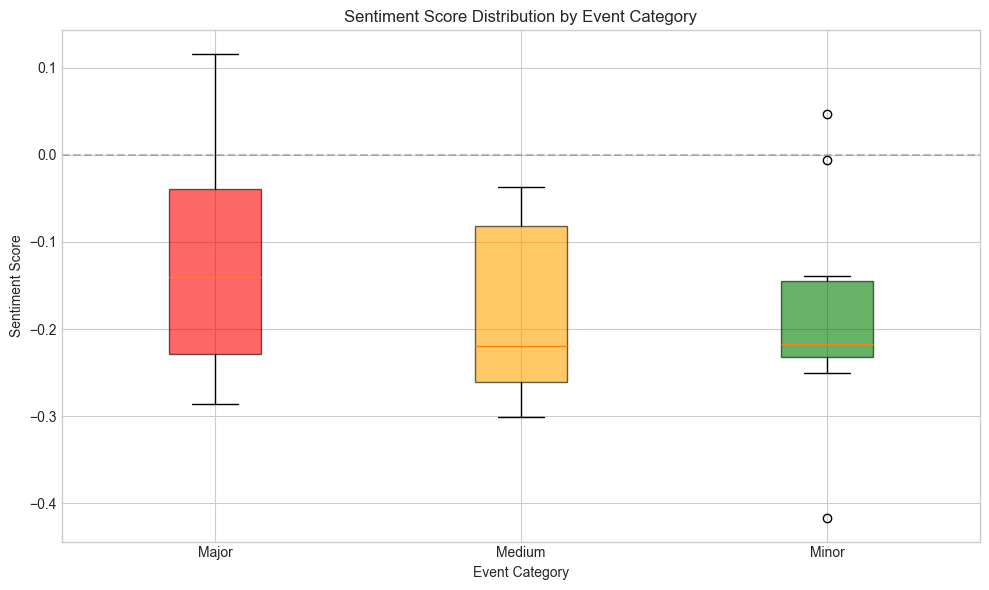


Sentiment Score by Category:
MAJOR    | Mean: -0.1189 | Std: 0.1504 | N: 6
MEDIUM   | Mean: -0.1809 | Std: 0.1142 | N: 6
MINOR    | Mean: -0.1823 | Std: 0.1304 | N: 10


In [102]:
# Box plot: Sentiment score by event category
fig, ax = plt.subplots(figsize=(10, 6))

categories = ['major', 'medium', 'minor']
data = [event_sentiment_df[event_sentiment_df['category'] == cat]['sentiment_score'].values 
        for cat in categories]

bp = ax.boxplot(data, labels=[cat.capitalize() for cat in categories], patch_artist=True)

colors = ['red', 'orange', 'green']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Event Category')
ax.set_ylabel('Sentiment Score')
ax.set_title('Sentiment Score Distribution by Event Category')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSentiment Score by Category:")
print("=" * 50)
for cat in categories:
    cat_data = event_sentiment_df[event_sentiment_df['category'] == cat]['sentiment_score']
    print(f"{cat.upper():8} | Mean: {cat_data.mean():+.4f} | Std: {cat_data.std():.4f} | N: {len(cat_data)}")

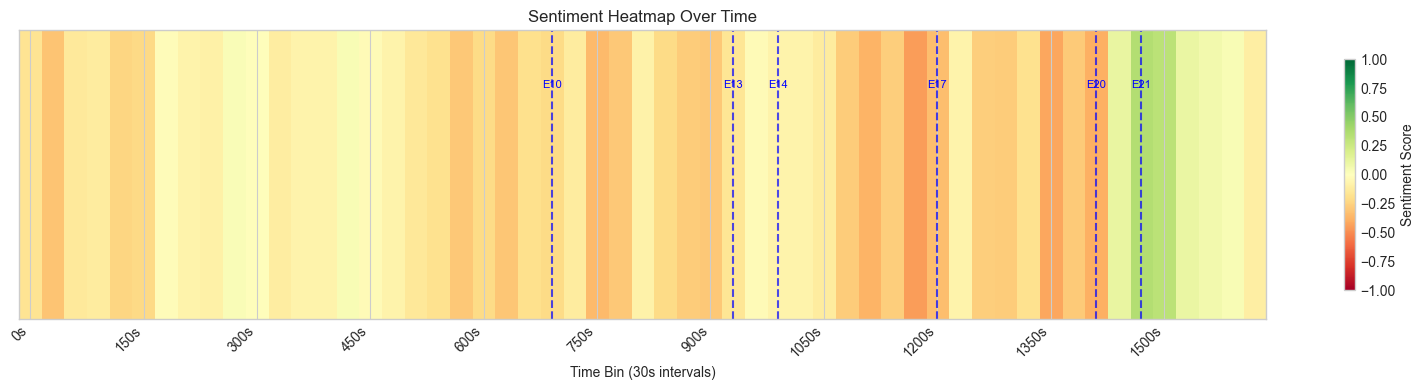

In [103]:
# Sentiment over time heatmap (binned by time)
fig, ax = plt.subplots(figsize=(16, 4))

# Bin comments by 30-second intervals
normalized_df['time_bin_30s'] = (normalized_df['occurence_timestamp'] // 30) * 30

# Calculate sentiment score per bin
sentiment_by_time = normalized_df.groupby('time_bin_30s')['sentiment'].apply(
    lambda x: (x == 'positive').sum() - (x == 'negative').sum()
) / normalized_df.groupby('time_bin_30s').size()

# Create heatmap data
heatmap_data = sentiment_by_time.values.reshape(1, -1)

im = ax.imshow(heatmap_data, aspect='auto', cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_yticks([])
ax.set_xlabel('Time Bin (30s intervals)')
ax.set_title('Sentiment Heatmap Over Time')

# Set x-axis labels
n_bins = len(sentiment_by_time)
tick_positions = range(0, n_bins, max(1, n_bins // 10))
tick_labels = [f"{int(sentiment_by_time.index[i])}s" for i in tick_positions]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, ha='right')

# Colorbar
cbar = plt.colorbar(im, ax=ax, orientation='vertical', shrink=0.8)
cbar.set_label('Sentiment Score')

# Mark major events
for _, event in normalized_event_df[normalized_event_df['category'] == 'major'].iterrows():
    bin_idx = event['timestamp'] // 30
    if bin_idx < n_bins:
        ax.axvline(x=bin_idx, color='blue', linestyle='--', alpha=0.7, linewidth=1.5)
        ax.text(bin_idx, -0.3, event['event_id'], ha='center', fontsize=8, color='blue')

plt.tight_layout()
plt.show()

In [104]:
# Final Summary
print("=" * 70)
print("SENTIMENT ANALYSIS SUMMARY")
print("=" * 70)
print(f"\nTotal comments analyzed: {len(normalized_df):,}")
print(f"Total events: {len(event_sentiment_df)}")
print()

print("Overall Sentiment Distribution:")
for sentiment, count in normalized_df['sentiment'].value_counts().items():
    pct = count / len(normalized_df) * 100
    print(f"  {sentiment.capitalize():10} : {count:,} ({pct:.1f}%)")

print()
print("Top 5 Most Positive Events:")
top_positive = event_sentiment_df.nlargest(5, 'sentiment_score')[['event_id', 'event', 'sentiment_score']]
for _, row in top_positive.iterrows():
    print(f"  {row['event_id']} ({row['event']}): {row['sentiment_score']:+.4f}")

print()
print("Top 5 Most Negative Events:")
top_negative = event_sentiment_df.nsmallest(5, 'sentiment_score')[['event_id', 'event', 'sentiment_score']]
for _, row in top_negative.iterrows():
    print(f"  {row['event_id']} ({row['event']}): {row['sentiment_score']:+.4f}")

print()
print(f"Output saved to: ../data/processed/event_sentiment.csv")
print("=" * 70)

SENTIMENT ANALYSIS SUMMARY

Total comments analyzed: 15,882
Total events: 22

Overall Sentiment Distribution:
  Negative   : 8,119 (51.1%)
  Positive   : 5,905 (37.2%)
  Neutral    : 1,858 (11.7%)

Top 5 Most Positive Events:
  E21 (match_selesai): +0.1160
  E22 (highlight_replay): +0.0469
  E04 (turtle_spawn_1): -0.0061
  E20 (war_besar_base): -0.0148
  E05 (first_blood): -0.0366

Top 5 Most Negative Events:
  E16 (lord_spawn_2): -0.4172
  E19 (defend_lord): -0.3009
  E17 (war_besar_lord): -0.2858
  E18 (lord_diamankan): -0.2615
  E06 (first_turret): -0.2581

Output saved to: ../data/processed/event_sentiment.csv
